In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -q --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 1.2 MB/s eta 0:00:00a 0:00:01


In [3]:
import yfinance as yf
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "JPM", 
           "JNJ", "PG", "XOM", "KO"]
START = "2015-01-01"
END   = "2024-12-31"

raw = yf.download(TICKERS, start = START, end = END,
                      auto_adjust = True)
raw.head()

[*********************100%***********************]  10 of 10 completed


Price           Close                                                       \
Ticker           AAPL     AMZN      GOOGL        JNJ        JPM         KO   
Date                                                                         
2015-01-02  24.171759  15.4260  26.244781  75.737366  46.066788  29.390270   
2015-01-05  23.490799  15.1095  25.744719  75.208420  44.636635  29.390270   
2015-01-06  23.493008  14.7645  25.109350  74.838837  43.479259  29.613455   
2015-01-07  23.822439  14.9210  25.035505  76.490967  43.545612  29.983088   
2015-01-08  24.737745  15.0230  25.122734  77.092407  44.518692  30.345758   

Price                                                   ...     Volume  \
Ticker           META       MSFT         PG        XOM  ...       AAPL   
Date                                                    ...              
2015-01-02  77.767097  39.607182  65.070000  56.777920  ...  212818400   
2015-01-05  76.518044  39.242950  64.760612  55.224361  ...  257142000   
2015-01-06  75.487106  38.666977  64.465645  54.930775  ...  263188400   
2015-01-07  75.487106  39.158257  64.803795  55.487350  ...  160423600   
2015-01-08  77.499435  40.310207  65.544861  56.410942  ...  237458000   

Price                                                                  \
Ticker          AMZN     GOOGL      JNJ       JPM        KO      META   
Date                                                                    
2015-01-02  55664000  26480000  5753600  12600000   9921100  18177500   
2015-01-05  55484000  41182000  8079300  20100600  26292600  26452200   
2015-01-06  70380000  54456000  7428000  29074100  16897500  27399300   
2015-01-07  52806000  46918000  7931700  23843200  13412300  22045300   
2015-01-08  61768000  73054000  9916000  16971100  21743600  23961000   

Price                                    
Ticker          MSFT       PG       XOM  
Date                                     
2015-01-02  27913900  7251400  10220400  
2015-01-05  39673900  8626100  18502400  
2015-01-06  36447900  7791200  16670700  
2015-01-07  29114100  5986600  13590700  
2015-01-08  29645200  6823300  15487500  

[5 rows x 50 columns]

In [4]:
close_prices = raw["Close"].copy()
print(close_prices.isna().sum())
print(close_prices.shape)

Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
KO       0
META     0
MSFT     0
PG       0
XOM      0
dtype: int64
(2515, 10)


In [5]:
print(close_prices.index.min(), close_prices.index.max())
print(close_prices.describe())

2015-01-02 00:00:00 2024-12-30 00:00:00
Ticker         AAPL         AMZN        GOOGL          JNJ          JPM  \
count   2515.000000  2515.000000  2515.000000  2515.000000  2515.000000   
mean      93.542514   101.186108    81.965210   118.742293   102.691631   
std       65.203343    54.133371    43.349326    26.954789    44.019590   
min       20.548140    14.347500    24.634562    67.197990    40.088207   
25%       35.107775    48.394751    46.960835    98.112156    71.290871   
50%       64.199028    94.565002    64.114983   117.134743    92.210106   
75%      149.811935   153.814995   118.637260   144.402229   131.512627   
max      257.153809   232.929993   195.638153   163.873474   241.669754   

Ticker           KO         META         MSFT           PG          XOM  
count   2515.000000  2515.000000  2515.000000  2515.000000  2515.000000  
mean      42.883880   220.265544   179.441703   100.584126    63.533208  
std       10.579521   120.693072   122.116478    34.149155    

In [6]:
MA_WINDOW = 50
ma = close_prices.rolling(window=MA_WINDOW).mean()
signal = close_prices > ma
signal.tail()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,PG,XOM
Date,,,,,,,,,,
2024-12-23,True,True,True,False,True,False,True,True,False,False
2024-12-24,True,True,True,False,True,False,True,True,False,False
2024-12-26,True,True,True,False,True,False,True,True,False,False
2024-12-27,True,True,True,False,True,False,True,True,False,False
2024-12-30,True,True,True,False,True,False,True,False,False,False


In [7]:
print(signal.sum())
print(signal.sum(axis=1).tail())

Ticker
AAPL     1603
AMZN     1667
GOOGL    1634
JNJ      1407
JPM      1645
KO       1548
META     1615
MSFT     1799
PG       1544
XOM      1330
dtype: int64
Date
2024-12-23    6
2024-12-24    6
2024-12-26    6
2024-12-27    6
2024-12-30    5
dtype: int64


In [8]:
positions = signal.shift(1).fillna(False).astype(float)
n_held = positions.sum(axis=1)
print(n_held)
weights = positions.div(n_held, axis=0).fillna(0)
print (weights)

Date
2015-01-02    0.0
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
             ... 
2024-12-23    5.0
2024-12-24    6.0
2024-12-26    6.0
2024-12-27    6.0
2024-12-30    6.0
Length: 2515, dtype: float64
Ticker          AAPL      AMZN     GOOGL  JNJ       JPM   KO      META  \
Date                                                                     
2015-01-02  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.000000   
2015-01-05  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.000000   
2015-01-06  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.000000   
2015-01-07  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.000000   
2015-01-08  0.000000  0.000000  0.000000  0.0  0.000000  0.0  0.000000   
...              ...       ...       ...  ...       ...  ...       ...   
2024-12-23  0.200000  0.200000  0.200000  0.0  0.200000  0.0  0.000000   
2024-12-24  0.166667  0.166667  0.166667  0.0  0.166667  0.0  0.166667   
2024-12-26  0.166667  0.1666

/tmp/ipykernel_58/1621349830.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions = signal.shift(1).fillna(False).astype(float)


In [9]:
weights.sum(axis=1).round(6).value_counts()

1.0    2405
0.0     110
Name: count, dtype: int64

In [10]:
asset_returns = close_prices.pct_change() 
portfolio_returns = (weights * asset_returns).sum(axis=1).fillna(0)
equity_curve = (1 + portfolio_returns).cumprod()




In [11]:
INITIAL_CAPITAL = 10_000
equity_curve_dollars = equity_curve * INITIAL_CAPITAL
print(portfolio_returns.describe())
print(equity_curve.iloc[-1])
print(equity_curve_dollars)

count    2515.000000
mean        0.000578
std         0.010392
min        -0.057665
25%        -0.003623
50%         0.000760
75%         0.005948
max         0.061059
dtype: float64
3.7310664188073
Date
2015-01-02    10000.000000
2015-01-05    10000.000000
2015-01-06    10000.000000
2015-01-07    10000.000000
2015-01-08    10000.000000
                  ...     
2024-12-23    37818.664194
2024-12-24    38296.430475
2024-12-26    38202.299858
2024-12-27    37733.893260
2024-12-30    37310.664188
Length: 2515, dtype: float64


In [12]:
turnover = weights.diff().abs().sum(axis=1)/2
print("Average daily turnover:", turnover.mean())
print("Total turnover (round trips):", turnover.sum())


Average daily turnover: 0.10787087001798733
Total turnover (round trips): 271.2952380952381


In [13]:
REBAL_FREQ = "ME"
rebal_dates = weights.resample(REBAL_FREQ).last().index
held = weights.loc[weights.index.isin(rebal_dates)].reindex(weights.index).ffill().fillna(0)


In [14]:
portfolio_returns = (held * asset_returns).sum(axis=1).fillna(0)
equity_curve = (1 + portfolio_returns).cumprod()

print("Monthly rebal:", equity_curve.iloc[-1])
print("New turnover:", (held.diff().abs().sum(axis=1) / 2).sum())

Monthly rebal: 4.961910234529812
New turnover: 35.84761904761905


In [15]:
TRADING_DAYS = 252
def performance(returns, name="stratedy"):
    equity = (1+returns).cumprod()
    total_return = equity.iloc[-1] -1
    years = len(returns)/TRADING_DAYS
    cagr = equity.iloc[-1]**(1/years) - 1

    vol = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = cagr / vol if vol > 0 else np.nan

    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()

    return pd.Series({
        "Total return": total_return,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max drawdown": max_dd,
    }, name=name)

    

In [16]:
bh_returns = asset_returns.mean(axis=1).fillna(0)   # equal-weight buy & hold

results = pd.concat([
    performance(portfolio_returns, "Screen (monthly)"),
    performance(bh_returns, "Buy & hold"),
], axis=1)

print(results.round(3))

              Screen (monthly)  Buy & hold
Total return             3.962       4.894
CAGR                     0.174       0.195
Volatility               0.183       0.182
Sharpe                   0.949       1.067
Max drawdown            -0.289      -0.310


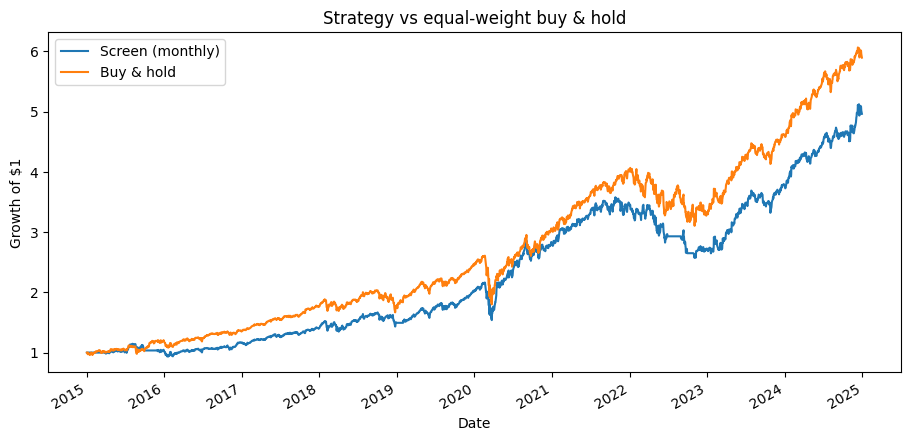

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 5))
(1 + portfolio_returns).cumprod().plot(ax=ax, label="Screen (monthly)")
(1 + bh_returns).cumprod().plot(ax=ax, label="Buy & hold")
ax.set_ylabel("Growth of $1")
ax.set_title("Strategy vs equal-weight buy & hold")
ax.legend()
plt.show()